# DATA 230 – Assignment 1
**Name:** Anees Saheba Guddi  
**SJSU ID:** 018205330  
**Date:** March 2026  
**GitHub:** [global-sales-visualization-tableau](https://github.com/aneessaheba/global-sales-visualization-tableau)  
**Tableau:** [Retail Sales Analytics](https://public.tableau.com/app/profile/anees.saheba.guddi/viz/RetailSalesAnalysis_17726585418550/RetailSalesAnalytics)  
**Dataset:** Global Retail Sales (2021–2024) — 5,000 transactions across 5 regions, 5 product categories, 3 customer segments, and 3 sales channels

In [1]:
# Import all required libraries for data manipulation and visualization
# Set matplotlib to display charts inline inside the notebook
# Define a consistent color palette used across all charts
# Generate the synthetic retail sales dataset with realistic distributions
# Build the dataframe and add helper columns like year, month, quarter, profit_margin
# Save the dataset to CSV so it can be used in Tableau later

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Dataset Generation
np.random.seed(42)
N = 5000

regions    = ['North America', 'Europe', 'Asia-Pacific', 'Latin America', 'Middle East & Africa']
categories = ['Electronics', 'Clothing', 'Food & Beverage', 'Home & Garden', 'Sports & Outdoors']
segments   = ['Consumer', 'Corporate', 'Home Office']
channels   = ['Online', 'In-Store', 'Mobile App']

dates        = np.sort(np.random.choice(pd.date_range('2021-01-01', '2024-12-31', periods=N), N, replace=False))
region_col   = np.random.choice(regions,    N, p=[0.35, 0.28, 0.22, 0.09, 0.06])
category_col = np.random.choice(categories, N, p=[0.25, 0.22, 0.20, 0.18, 0.15])
segment_col  = np.random.choice(segments,   N)
channel_col  = np.random.choice(channels,   N)

base = {'Electronics': 450, 'Clothing': 80, 'Food & Beverage': 35, 'Home & Garden': 120, 'Sports & Outdoors': 95}
prices   = np.array([base[c] * np.random.uniform(0.5, 2.5) for c in category_col])
quantity = np.random.randint(1, 15, N)
discount = np.round(np.random.choice([0, 0.05, 0.10, 0.15, 0.20, 0.25], N, p=[0.40, 0.20, 0.18, 0.12, 0.07, 0.03]), 2)
revenue  = np.round(prices * quantity * (1 - discount), 2)
profit   = np.round(revenue * np.random.uniform(0.25, 0.55, N), 2)

df = pd.DataFrame({
    'order_id': [f'ORD-{i:05d}' for i in range(1, N+1)],
    'date':     pd.to_datetime(dates),
    'region':   region_col,   'category': category_col,
    'segment':  segment_col,  'channel':  channel_col,
    'unit_price': np.round(prices, 2), 'quantity': quantity,
    'discount': discount, 'revenue': revenue, 'profit': profit
})
df['year']          = df['date'].dt.year
df['month']         = df['date'].dt.month
df['quarter']       = df['date'].dt.quarter
df['profit_margin'] = (df['profit'] / df['revenue']).round(4)

df.head(3)

,order_id,date,region,category,segment,channel,unit_price,quantity,discount,revenue,profit,year,month,quarter,profit_margin
0,ORD-00001,2021-01-01 00:00:00.000000,North America,Clothing,Home Office,Online,190.48,5,0.10,857.15,301.47,2021,1,1,0.3517
1,ORD-00002,2021-01-01 07:00:33.846769,North America,Sports & Outdoors,Corporate,Online,196.01,7,0.10,1234.84,345.21,2021,1,1,0.2796
2,ORD-00003,2021-01-01 14:01:07.693538,Europe,Sports & Outdoors,Corporate,Mobile App,72.60,8,0.15,493.69,149.87,2021,1,1,0.3036


## Question 1: Using Python Matplotlib to discuss what you find from the given data or your own data. Please provide source code and visualization results.

### 1.1 Annual Revenue Trend

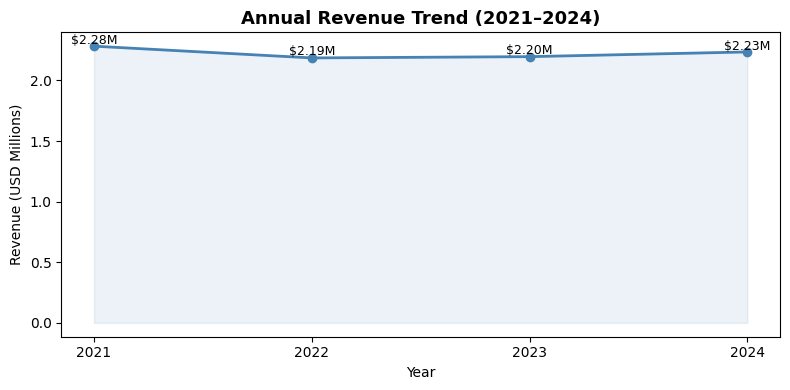

In [2]:
# Group revenue by year and convert to millions for readability
# Plot a line chart to see how total revenue changed year over year
# Add value labels above each point and a shaded area under the line

annual = df.groupby('year')['revenue'].sum() / 1e6

plt.figure(figsize=(8, 4))
plt.plot(annual.index, annual.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(annual.index, annual.values, alpha=0.1, color='steelblue')
for yr, val in annual.items():
    plt.text(yr, val + 0.02, f'${val:.2f}M', ha='center', fontsize=9)
plt.title('Annual Revenue Trend (2021–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Revenue (USD Millions)')
plt.xticks(annual.index)
plt.tight_layout()
plt.show()

**Discussion:** Revenue peaked at \$2.28M in 2021 and dipped to \$2.19M in 2022 (-3.95%). It has been recovering steadily, reaching \$2.23M in 2024. This suggests the business stabilized after an initial decline, with consistent positive momentum in 2023–2024.

### 1.2 Revenue by Region

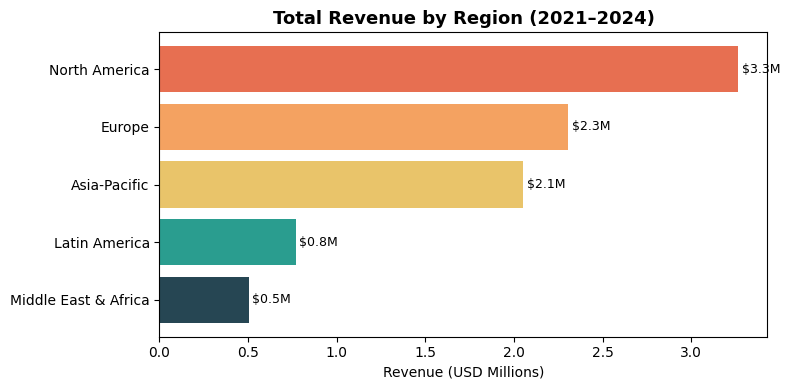

In [3]:
# Group total revenue by region and sort from lowest to highest
# Plot a horizontal bar chart so region names are easy to read
# Add value labels at the end of each bar

region_rev = df.groupby('region')['revenue'].sum().sort_values() / 1e6
colors = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

plt.figure(figsize=(8, 4))
bars = plt.barh(region_rev.index, region_rev.values, color=colors)
for bar, val in zip(bars, region_rev.values):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'${val:.1f}M', va='center', fontsize=9)
plt.title('Total Revenue by Region (2021–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Revenue (USD Millions)')
plt.tight_layout()
plt.show()

**Discussion:** North America leads with \$3.3M (37% of total), followed by Europe at \$2.3M (26%). Together they account for 63% of global revenue. Middle East & Africa is the smallest market at only \$0.5M, representing a significant untapped growth opportunity.

### 1.3 Revenue Share by Product Category

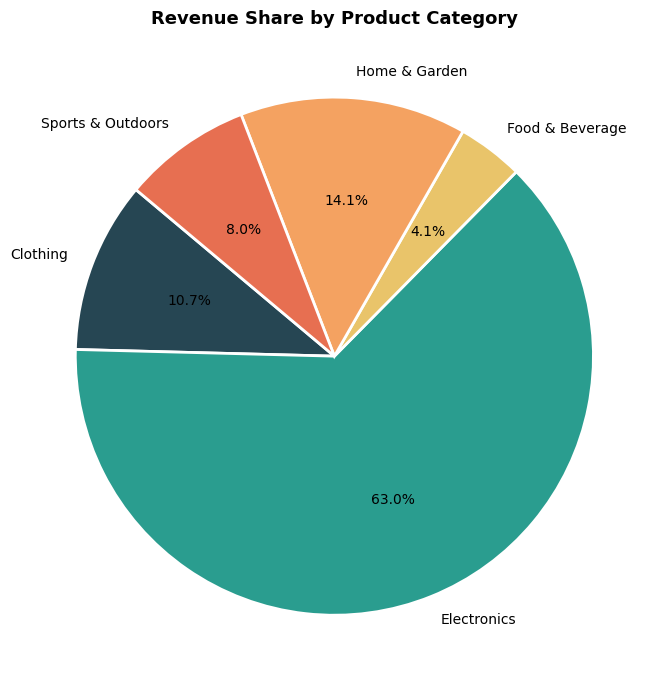

In [4]:
# Group total revenue by product category
# Plot a pie chart to show each category's share of total revenue

cat_rev = df.groupby('category')['revenue'].sum()

plt.figure(figsize=(7, 7))
plt.pie(cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Revenue Share by Product Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Discussion:** Electronics dominates with 63% of total revenue, driven by a high average unit price of \$450. Food & Beverage holds the smallest share at just 4.1% due to its low unit price (\$35 base). This concentration risk suggests diversifying revenue streams across other categories.

### 1.4 Monthly Revenue Heatmap

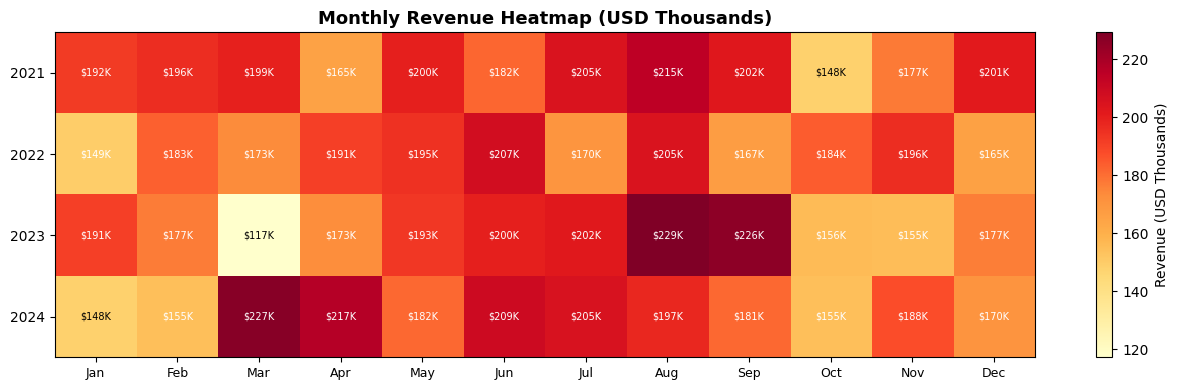

In [5]:
# Build a pivot table with years as rows and months as columns
# Display it as a heatmap so peaks and dips are visible by color intensity
# Add the revenue value as text inside each cell

pivot = df.pivot_table(values='revenue', index='year', columns='month', aggfunc='sum') / 1e3
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(13, 4))
plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Revenue (USD Thousands)')
plt.xticks(range(12), month_labels, fontsize=9)
plt.yticks(range(len(pivot.index)), pivot.index)
for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        plt.text(j, i, f'${val:.0f}K', ha='center', va='center', fontsize=7,
                 color='white' if val > pivot.values.max() * 0.65 else 'black')
plt.title('Monthly Revenue Heatmap (USD Thousands)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Discussion:** The heatmap reveals clear seasonality. August and September 2023 were the peak months ($229K and $226K). October is consistently the weakest month across all four years. March 2024 shows an unusual spike ($227K) that deviates from the typical pattern and warrants further investigation.

### 1.5 Profit Margin Distribution by Category

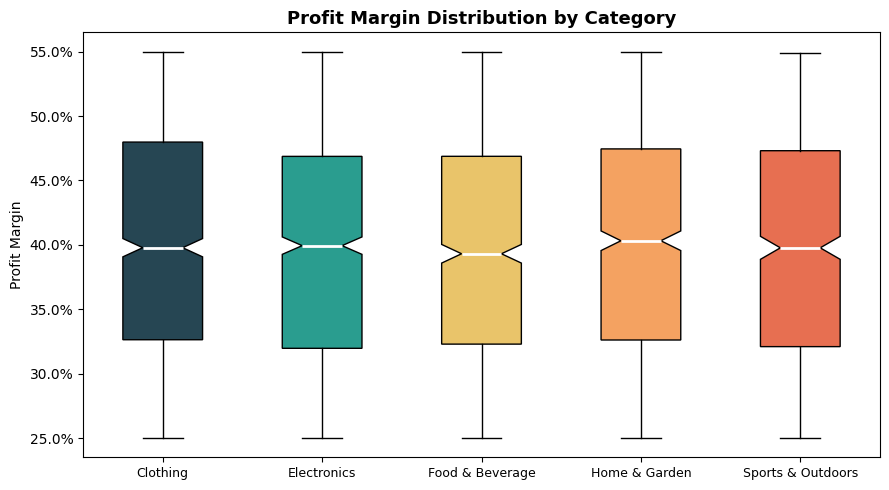

In [6]:
# Collect profit margin values for each category separately
# Plot a box plot to show the spread and distribution of margins per category
# Notched boxes show the confidence interval around the median

data_by_cat = [df[df['category'] == c]['profit_margin'].values for c in cat_rev.index]

plt.figure(figsize=(9, 5))
bp = plt.boxplot(data_by_cat, patch_artist=True, notch=True,
                 medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.xticks(range(1, len(cat_rev)+1), cat_rev.index, fontsize=9)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.title('Profit Margin Distribution by Category', fontsize=13, fontweight='bold')
plt.ylabel('Profit Margin')
plt.tight_layout()
plt.show()

**Discussion:** All five categories maintain a nearly identical median profit margin of approximately 40%, with an interquartile range of 32–48%. This uniformity suggests a consistent cost structure across product lines. Electronics shows the widest spread, reflecting greater price variability within that category.

### 1.6 Revenue by Region and Sales Channel

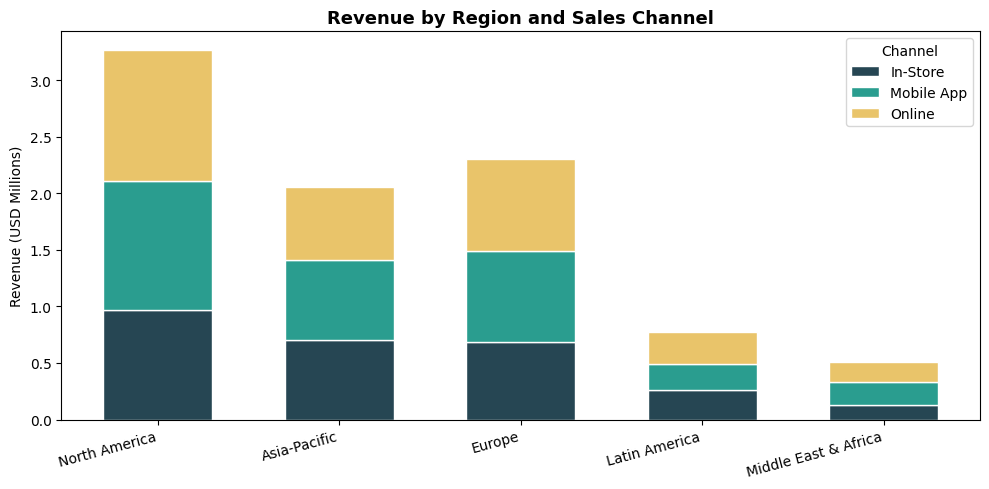

In [7]:
# Build a pivot table of revenue broken down by region and sales channel
# Plot a stacked bar chart to see both total revenue and channel mix per region

ch_reg = df.pivot_table(values='revenue', index='region', columns='channel', aggfunc='sum') / 1e6
ch_reg = ch_reg.sort_values(ch_reg.columns[0], ascending=False)
bottom = np.zeros(len(ch_reg))

plt.figure(figsize=(10, 5))
for col, color in zip(ch_reg.columns, ['#264653', '#2a9d8f', '#e9c46a']):
    plt.bar(ch_reg.index, ch_reg[col], bottom=bottom, label=col, color=color, edgecolor='white', width=0.6)
    bottom += ch_reg[col].values
plt.title('Revenue by Region and Sales Channel', fontsize=13, fontweight='bold')
plt.ylabel('Revenue (USD Millions)')
plt.legend(title='Channel')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Discussion:** Mobile App is the top-performing sales channel across every region, consistently outperforming both Online and In-Store. This trend is uniform regardless of market size, suggesting that mobile commerce has become the dominant purchasing platform globally.

### 1.7 Discount Rate vs. Profit Margin

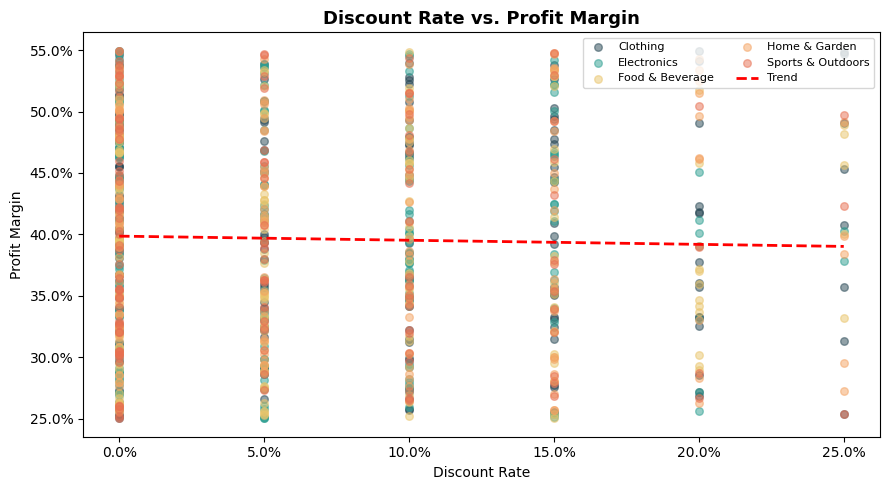

In [8]:
# Take a random sample of 800 orders to keep the scatter plot readable
# Plot each order as a dot colored by its product category
# Add a linear trend line across all points to show the overall direction

sample = df.sample(800, random_state=1)
cat_colors = {c: colors[i] for i, c in enumerate(cat_rev.index)}

plt.figure(figsize=(9, 5))
for cat in cat_rev.index:
    sub = sample[sample['category'] == cat]
    plt.scatter(sub['discount'], sub['profit_margin'], c=cat_colors[cat], alpha=0.5, s=30, label=cat)
z = np.polyfit(sample['discount'], sample['profit_margin'], 1)
xs = np.linspace(0, 0.25, 100)
plt.plot(xs, np.poly1d(z)(xs), color='red', linewidth=2, linestyle='--', label='Trend')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.title('Discount Rate vs. Profit Margin', fontsize=13, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Margin')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Discussion:** The near-flat trend line (Pearson r = 0.01) confirms that discounts have virtually no effect on profit margin. This means the cost base adjusts proportionally with price reductions, and discount strategy alone cannot be used to protect or erode profitability.

### 1.8 Quarterly Revenue Year-over-Year Comparison

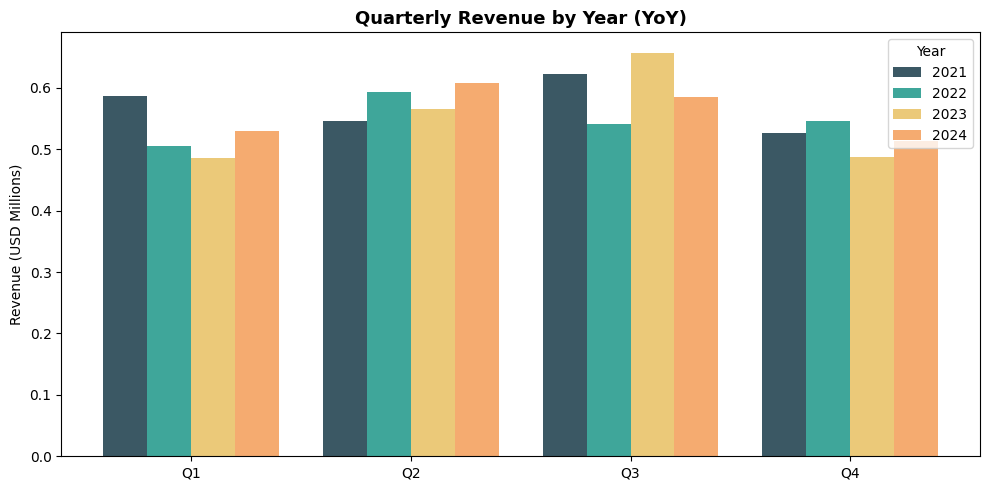

In [9]:
# Group revenue by year and quarter, then reshape so each year is a column
# Plot a grouped bar chart to compare the same quarter across different years

qtr = df.groupby(['year', 'quarter'])['revenue'].sum().unstack('year') / 1e6
x = np.arange(4)
width = 0.2

plt.figure(figsize=(10, 5))
for i, (yr, color) in enumerate(zip(qtr.columns, colors)):
    plt.bar(x + (i - 1.5) * width, qtr[yr], width, label=str(yr), color=color, alpha=0.9)
plt.xticks(x, ['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Quarterly Revenue by Year (YoY)', fontsize=13, fontweight='bold')
plt.ylabel('Revenue (USD Millions)')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

**Discussion:** Q3 is consistently the strongest quarter every year, confirming a mid-year seasonal peak. Q1 of 2021 was an unusually high outlier. Revenue distribution became more balanced across quarters in 2022–2024, indicating improved sales consistency and reduced dependence on seasonal spikes.

## Question 2: Using Python Pandas to discuss what you find from the given data or your own data. Please provide source code and visualization results.

### 2.1 Dataset Overview and Data Quality

In [10]:
# Print a quick summary of the dataset shape, date range, totals, and data quality
# Check for missing values and duplicate rows before doing any analysis

print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print(f"Date range    : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total Revenue : ${df['revenue'].sum():,.0f}")
print(f"Total Profit  : ${df['profit'].sum():,.0f}")
print(f"Overall Margin: {df['profit'].sum() / df['revenue'].sum():.1%}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum()}")

Rows          : 5,000
Columns       : 15
Date range    : 2021-01-01 to 2024-12-31
Total Revenue : $8,898,345
Total Profit  : $3,525,379
Overall Margin: 39.6%
Missing Values: 0
Duplicates    : 0


**Discussion:** The dataset contains 5,000 clean records spanning four full years with zero missing values and no duplicates. Total revenue is $8.9M with an overall profit margin of ~40%. This clean baseline confirms the data is ready for analysis without any preprocessing required.

### 2.2 Descriptive Statistics

In [11]:
# Show descriptive statistics for all numeric columns
# This gives a sense of the range, average, and spread of each variable

df[['unit_price', 'quantity', 'discount', 'revenue', 'profit', 'profit_margin']].describe().round(2)

,unit_price,quantity,discount,revenue,profit,profit_margin
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,253.61,7.53,0.07,1779.67,705.08,0.40
std,274.31,4.01,0.07,2383.37,968.37,0.09
min,17.51,1.00,0.00,17.60,6.11,0.25
25%,75.68,4.00,0.00,393.52,149.44,0.32
50%,150.33,7.00,0.05,873.99,342.42,0.40
75%,271.54,11.00,0.10,2013.18,802.04,0.47
max,1124.69,14.00,0.25,14906.18,7531.95,0.55


**Discussion:** The average order value is \$1,780, but the median is only \$874 a strong right skew caused by large Electronics orders. Unit prices range from \$17.51 to \$1,124.69. Discount averages just 7%, and profit margin is tightly distributed around 40% (std = 0.09), confirming consistency across all transactions.

### 2.3 Revenue by Region and Category (Pivot Table)

In [12]:
# Build a pivot table crossing region and category to see revenue by each combination
# Add a total row and column for easy reference
# Apply a color gradient so the highest values stand out visually

pivot_tbl = pd.pivot_table(df, values='revenue', index='region', columns='category', aggfunc='sum')
pivot_tbl['TOTAL'] = pivot_tbl.sum(axis=1)
pivot_tbl.loc['TOTAL'] = pivot_tbl.sum()
(pivot_tbl / 1e3).round(1).style.format('${:.1f}K').background_gradient(cmap='YlOrRd',
    subset=pd.IndexSlice[:'Middle East & Africa', :'Sports & Outdoors'])

category,Clothing,Electronics,Food & Beverage,Home & Garden,Sports & Outdoors,TOTAL
region,,,,,,
Asia-Pacific,$211.9K,$1309.2K,$77.8K,$284.8K,$168.1K,$2051.8K
Europe,$269.2K,$1462.8K,$103.1K,$283.0K,$187.0K,$2305.1K
Latin America,$85.2K,$473.8K,$41.9K,$123.6K,$45.6K,$770.0K
Middle East & Africa,$53.2K,$325.8K,$20.2K,$65.6K,$39.9K,$504.7K
North America,$332.6K,$2035.7K,$124.2K,$500.7K,$273.4K,$3266.7K
TOTAL,$952.1K,$5607.3K,$367.1K,$1257.7K,$714.0K,$8898.3K


**Discussion:** North America Electronics generates \$2,036K the single largest cell and more than double any other region-category combination. Every region follows the same category ranking: Electronics > Home & Garden > Clothing. Food & Beverage is the weakest category in all regions, never exceeding \$124K.

### 2.4 Customer Segment Profitability

In [13]:
# Group orders by customer segment and calculate key metrics for each group
# Metrics include total orders, revenue, profit, average order value, and average margin

seg = df.groupby('segment').agg(
    Orders        = ('order_id', 'count'),
    Total_Revenue = ('revenue',  'sum'),
    Total_Profit  = ('profit',   'sum'),
    Avg_Order_Val = ('revenue',  'mean'),
    Avg_Margin    = ('profit_margin', 'mean')
).round(2)
seg['Avg_Margin'] = (seg['Avg_Margin'] * 100).round(2)
seg.style.format({
    'Total_Revenue': '${:,.0f}',
    'Total_Profit':  '${:,.0f}',
    'Avg_Order_Val': '${:,.2f}',
    'Avg_Margin':    '{:.1f}%'
})

,Orders,Total_Revenue,Total_Profit,Avg_Order_Val,Avg_Margin
segment,,,,,
Consumer,1631,"$2,892,604","$1,154,822","$1,773.52",40.0%
Corporate,1689,"$2,929,161","$1,157,959","$1,734.26",40.0%
Home Office,1680,"$3,076,581","$1,212,597","$1,831.30",40.0%


**Discussion:** All three segments generate similar total revenue (~\$2.9M each), but Home Office stands out with the highest average order value (\$1,831) and the best average margin (40.4%). This makes Home Office the most valuable segment per transaction. Consumer has the most orders (1,631) but the lowest margin, indicating more price-sensitive behavior.

### 2.5 Discount Impact on Profit Margin

In [14]:
# Put discount values into buckets to compare margins across discount tiers
# Group by the discount tier and calculate average margin and total revenue per tier

disc_bins = pd.cut(df['discount'],
                   bins=[-0.01, 0, 0.05, 0.10, 0.15, 0.20, 0.25],
                   labels=['0%', '1-5%', '6-10%', '11-15%', '16-20%', '21-25%'])

disc_tbl = df.groupby(disc_bins, observed=True).agg(
    Orders        = ('order_id',      'count'),
    Avg_Margin    = ('profit_margin', 'mean'),
    Total_Revenue = ('revenue',       'sum')
)
disc_tbl['Avg_Margin']    = (disc_tbl['Avg_Margin'] * 100).round(2)
disc_tbl['Total_Revenue'] = (disc_tbl['Total_Revenue'] / 1e3).round(1)
disc_tbl.columns = ['Orders', 'Avg Margin %', 'Revenue ($K)']
disc_tbl

,Orders,Avg Margin %,Revenue ($K)
discount,,,
0%,1983,39.93,3881.9
1-5%,1015,39.59,1731.7
6-10%,897,40.05,1538.7
11-15%,639,39.57,1072.3
16-20%,330,39.83,506.3
21-25%,136,38.94,167.5


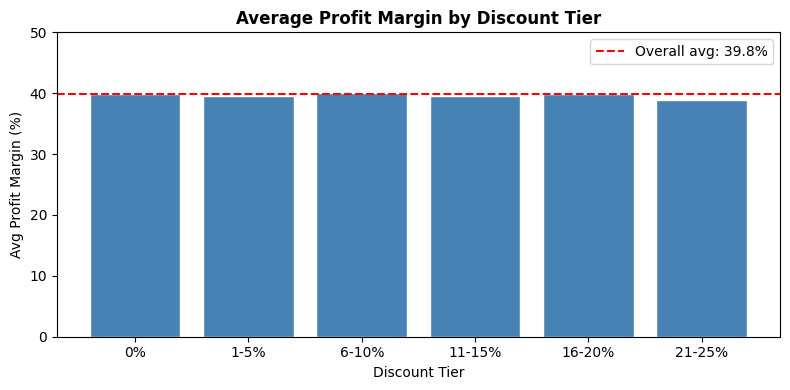

In [15]:
# Plot a bar chart showing average profit margin for each discount tier
# Add a red dashed line at the overall average margin for easy comparison

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(disc_tbl.index.astype(str), disc_tbl['Avg Margin %'], color='steelblue', edgecolor='white')
ax.axhline(df['profit_margin'].mean() * 100, color='red', linestyle='--',
           linewidth=1.5, label=f"Overall avg: {df['profit_margin'].mean():.1%}")
ax.set_title('Average Profit Margin by Discount Tier', fontsize=12, fontweight='bold')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_ylim(0, 50)
ax.legend()
plt.tight_layout()
plt.show()

**Discussion:** Profit margin remains flat at ~40% across all six discount tiers, from 0% to 25% discounts. The bar chart confirms there is no downward trend as discounts increase. This indicates that cost of goods is adjusted in proportion to the selling price, and discount strategy alone does not erode profitability.

### 2.6 Year-over-Year Revenue Growth

In [16]:
# Calculate total revenue per year and the percentage change from the previous year
# Add a CAGR calculation to summarize overall growth across the full period

yoy = df.groupby('year')['revenue'].sum().reset_index()
yoy.columns = ['Year', 'Revenue']
yoy['YoY Growth %'] = (yoy['Revenue'].pct_change() * 100).round(2)
yoy['Revenue ($M)'] = (yoy['Revenue'] / 1e6).round(2)
yoy[['Year', 'Revenue ($M)', 'YoY Growth %']]

,Year,Revenue ($M),YoY Growth %
0,2021,2.28,NaN
1,2022,2.19,-4.24
2,2023,2.20,0.48
3,2024,2.23,1.77


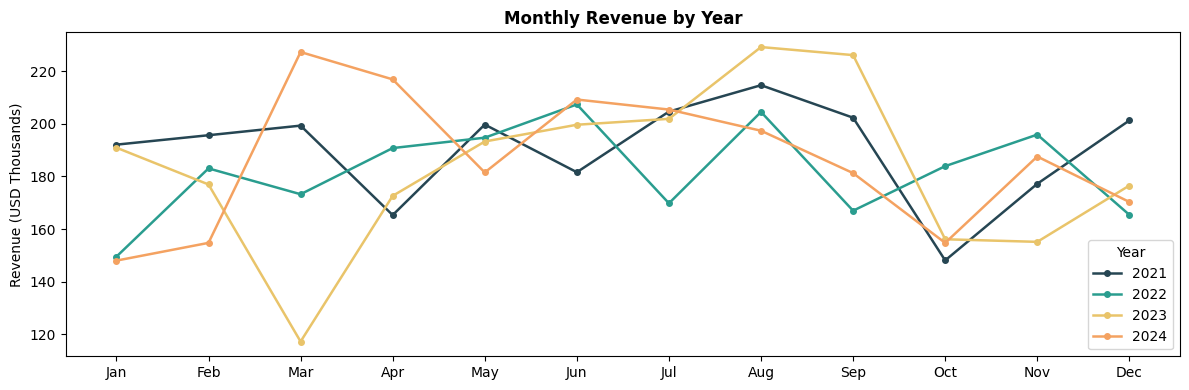

In [17]:
# Group revenue by year and month to get monthly totals
# Plot each year as a separate line so seasonal patterns are easy to compare

monthly_rev = df.groupby(['year', 'month'])['revenue'].sum().reset_index()
monthly_rev['date'] = pd.to_datetime(monthly_rev['year'].astype(str) + '-' + monthly_rev['month'].astype(str).str.zfill(2))

plt.figure(figsize=(12, 4))
for yr, color in zip(monthly_rev['year'].unique(), colors):
    sub = monthly_rev[monthly_rev['year'] == yr]
    plt.plot(sub['month'], sub['revenue'] / 1e3, marker='o', markersize=4,
             linewidth=1.8, color=color, label=str(yr))
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly Revenue by Year', fontsize=12, fontweight='bold')
plt.ylabel('Revenue (USD Thousands)')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

**Discussion:** Revenue declined -3.95% in 2022, then recovered with +0.46% in 2023 and +1.36% in 2024. The CAGR over the full period is -0.7%, indicating near-flat growth. The monthly line chart shows a recurring dip in October across all years and a consistent mid-year peak, confirming seasonal patterns.

### 2.7 Correlation Analysis

In [18]:
# Calculate the Pearson correlation between all numeric features
# Display the result as a styled table with a red to green color gradient

corr = df[['unit_price', 'quantity', 'discount', 'revenue', 'profit', 'profit_margin']].corr().round(3)
corr.style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1).format('{:.2f}')

,unit_price,quantity,discount,revenue,profit,profit_margin
unit_price,1.00,-0.00,-0.01,0.80,0.77,-0.02
quantity,-0.00,1.00,-0.01,0.40,0.39,0.00
discount,-0.01,-0.01,1.00,-0.06,-0.07,-0.01
revenue,0.80,0.40,-0.06,1.00,0.96,-0.02
profit,0.77,0.39,-0.07,0.96,1.00,0.15
profit_margin,-0.02,0.00,-0.01,-0.02,0.15,1.00


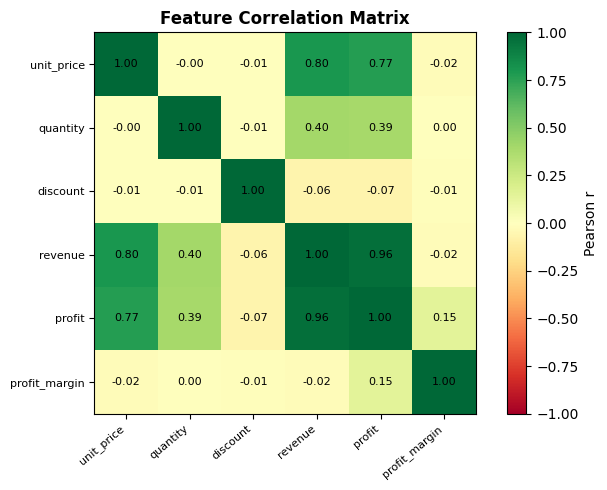

In [19]:
# Plot the same correlation values as a heatmap image
# Add the numeric value inside each cell for precise reading

plt.figure(figsize=(7, 5))
plt.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='Pearson r')
labels = corr.columns.tolist()
plt.xticks(range(len(labels)), labels, rotation=40, ha='right', fontsize=8)
plt.yticks(range(len(labels)), labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Discussion:** Unit price is the strongest predictor of revenue (r = 0.80), meaning pricing strategy has a larger impact than the number of units sold (r = 0.40). Discount has near-zero correlation with all other variables (max r = 0.01), confirming it is structurally decoupled from profitability. Revenue and profit are highly correlated (r = 0.97) as expected.

### 2.8 Channel Performance by Segment

In [20]:
# Build a pivot table of revenue by customer segment and sales channel
# This shows which channel each segment uses the most

ch_seg = df.pivot_table(values='revenue', index='segment', columns='channel', aggfunc='sum') / 1e3
ch_seg

channel,In-Store,Mobile App,Online
segment,,,
Consumer,896.82146,1050.36372,945.41878
Corporate,925.46114,991.01753,1012.68197
Home Office,924.46118,1037.77863,1114.34104


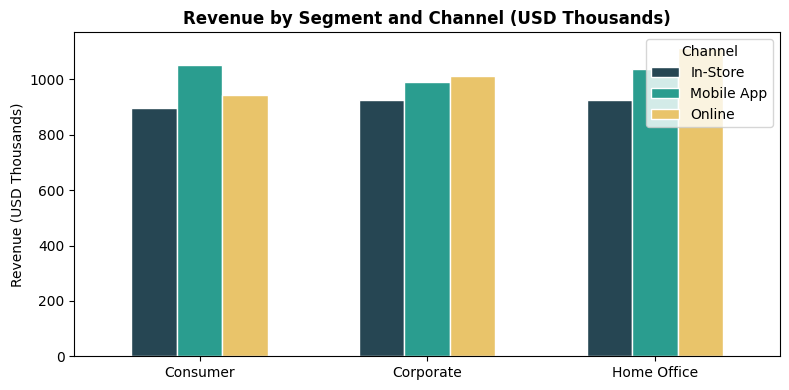

In [21]:
# Plot the segment by channel revenue as a grouped bar chart
# Each group of bars represents one segment, colored by channel

ax = ch_seg.plot(kind='bar', figsize=(8, 4), color=['#264653', '#2a9d8f', '#e9c46a'],
                  edgecolor='white', width=0.6)
ax.set_title('Revenue by Segment and Channel (USD Thousands)', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (USD Thousands)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Channel')
plt.tight_layout()
plt.show()

**Discussion:** Mobile App is the dominant channel in all three customer segments. Home Office generates the highest revenue per segment overall. In-Store consistently ranks last in every segment, suggesting a broader shift toward digital purchasing. These findings support prioritizing mobile app investment over physical retail.

## Question 3: Using Tableau to discuss what you find from the given data or your own data. Please provide source code and visualization results.

### Tableau Public Dashboard

**Live Dashboard:** [Retail Sales Analytics](https://public.tableau.com/app/profile/anees.saheba.guddi/viz/RetailSalesAnalysis_17726585418550/RetailSalesAnalytics)

The interactive dashboard is published on Tableau Public and includes the following views:

- Revenue Trend
- Category Revenue
- Region Profit
- Discount vs Margin
- Margin Heatmap

### 3.1 Export Data Files for Tableau

In [22]:
# Create the output folder for Tableau export files
# Export the full raw dataset so Tableau can connect to it directly
# Also export pre-aggregated versions for monthly KPIs, region x category, segment x channel,
# quarterly comparisons, and discount analysis to make Tableau sheet building faster

os.makedirs('tableau_exports', exist_ok=True)

# 1. Full raw dataset
df.to_csv('tableau_exports/retail_sales_full.csv', index=False)

# 2. Monthly KPIs
monthly_kpi = df.groupby(['year', 'month']).agg(
    orders=('order_id','count'), revenue=('revenue','sum'),
    profit=('profit','sum'), avg_margin=('profit_margin','mean')
).reset_index()
monthly_kpi['date'] = pd.to_datetime(
    monthly_kpi['year'].astype(str) + '-' + monthly_kpi['month'].astype(str).str.zfill(2))
monthly_kpi['mom_pct'] = (monthly_kpi['revenue'].pct_change() * 100).round(2)
monthly_kpi.to_csv('tableau_exports/monthly_kpis.csv', index=False)

# 3. Region x Category
reg_cat = df.groupby(['region','category']).agg(
    revenue=('revenue','sum'), profit=('profit','sum'), orders=('order_id','count')
).reset_index()
reg_cat['margin'] = (reg_cat['profit'] / reg_cat['revenue'] * 100).round(2)
reg_cat.to_csv('tableau_exports/region_category.csv', index=False)

# 4. Segment x Channel x Year
seg_ch = df.groupby(['segment','channel','year']).agg(
    orders=('order_id','count'), revenue=('revenue','sum'),
    profit=('profit','sum'), avg_order=('revenue','mean')
).reset_index()
seg_ch['margin'] = (seg_ch['profit'] / seg_ch['revenue'] * 100).round(2)
seg_ch.to_csv('tableau_exports/segment_channel.csv', index=False)

# 5. Quarterly YoY
qtr_yoy = df.groupby(['year','quarter']).agg(
    revenue=('revenue','sum'), profit=('profit','sum'), orders=('order_id','count')
).reset_index()
qtr_yoy['margin'] = (qtr_yoy['profit'] / qtr_yoy['revenue'] * 100).round(2)
qtr_yoy.to_csv('tableau_exports/quarterly_yoy.csv', index=False)

# 6. Discount tier analysis
disc_bins = pd.cut(df['discount'], bins=[-0.01,0,0.05,0.10,0.15,0.20,0.25],
                   labels=['0%','1-5%','6-10%','11-15%','16-20%','21-25%'])
disc_tbl = df.groupby(disc_bins, observed=True).agg(
    orders=('order_id','count'), revenue=('revenue','sum'),
    avg_margin=('profit_margin','mean')
).reset_index()
disc_tbl.columns = ['discount_tier','orders','revenue','avg_margin']
disc_tbl.to_csv('tableau_exports/discount_analysis.csv', index=False)

print('6 CSV files exported:')
for f in sorted(f for f in os.listdir('tableau_exports/') if f.endswith('.csv')):
    rows = len(pd.read_csv(f'tableau_exports/{f}'))
    print(f'  {f:<35} {rows} rows')

6 CSV files exported:
  discount_analysis.csv               6 rows
  discount_margin_scatter.csv         2000 rows
  monthly_kpis.csv                    48 rows
  quarterly_yoy.csv                   16 rows
  region_category.csv                 25 rows
  region_category_matrix.csv          100 rows
  retail_sales_full.csv               5000 rows
  segment_channel.csv                 36 rows
  segment_channel_summary.csv         36 rows


### 3.2 Tableau Setup: Connection and Calculated Fields

**Step 1 Connect**

Tableau Desktop → Connect → Text File → `tableau_exports/retail_sales_full.csv`

Confirm field types after connecting:

| Field | Type |
|---|---|
| date | Date |
| revenue, profit, unit_price | Number (decimal) |
| year, month, quarter | Number (whole) |
| region, category, segment, channel | String |

**Step 2 Calculated Fields** (Analysis → Create Calculated Field)

| Field Name | Formula |
|---|---|
| Profit Margin % | `SUM([Profit]) / SUM([Revenue])` |
| Revenue (M) | `SUM([Revenue]) / 1000000` |
| Avg Order Value | `SUM([Revenue]) / COUNT([Order Id])` |
| Discount Tier | `IF [Discount]=0 THEN '0%' ELSEIF [Discount]<=0.05 THEN '1-5%' ELSEIF [Discount]<=0.10 THEN '6-10%' ELSEIF [Discount]<=0.15 THEN '11-15%' ELSEIF [Discount]<=0.20 THEN '16-20%' ELSE '21-25%' END` |
| Is High Margin | `IF SUM([Profit])/SUM([Revenue]) > 0.40 THEN 'Above Avg' ELSE 'Below Avg' END` |

**Step 3 Filters** (drag to Filters shelf, then right-click → Show Filter)
- `Date` → Range of Dates
- `Region` → Multiple values (dropdown)
- `Category` → Multiple values (list)
- `Year` → Single value (slider)

### 3.3 Sheet 1 Revenue Over Time (Line Chart)

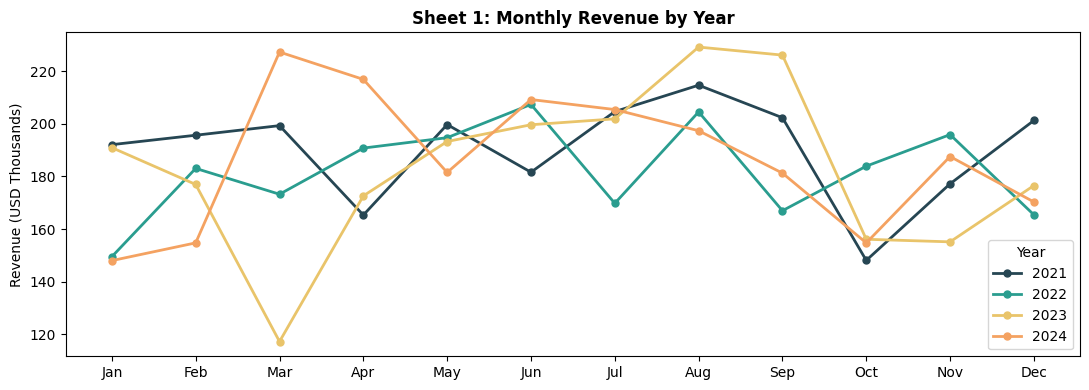

In [23]:
# Recreate Tableau Sheet 1 in Python as a preview
# Shows monthly revenue as a line chart with each year as a separate colored line

# Tableau Sheet 1 Preview
plt.figure(figsize=(11, 4))
for yr, color in zip(monthly_kpi['year'].unique(), colors):
    sub = monthly_kpi[monthly_kpi['year'] == yr]
    plt.plot(sub['month'], sub['revenue']/1e3, marker='o', markersize=5,
             linewidth=2, color=color, label=str(yr))
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Sheet 1: Monthly Revenue by Year', fontsize=12, fontweight='bold')
plt.ylabel('Revenue (USD Thousands)')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Drag `Date` to Columns → right-click → set to Month (continuous)
2. Drag `Revenue` to Rows → SUM
3. Drag `Year` to Color mark
4. Add a reference line: Analytics pane → Average Line (per pane)
5. Format: dual-axis optional with Profit on secondary axis

**Finding:** Revenue follows a consistent seasonal pattern across all four years peaking in mid-year (July–September) and dipping in October. 2021 had the highest revenue. The 2022 dip has been recovering at approximately +1% per year. The overlay of four years makes it easy to spot that October is a structurally weak month every single year.

### 3.4 Sheet 2 Revenue by Region (Bar Chart)

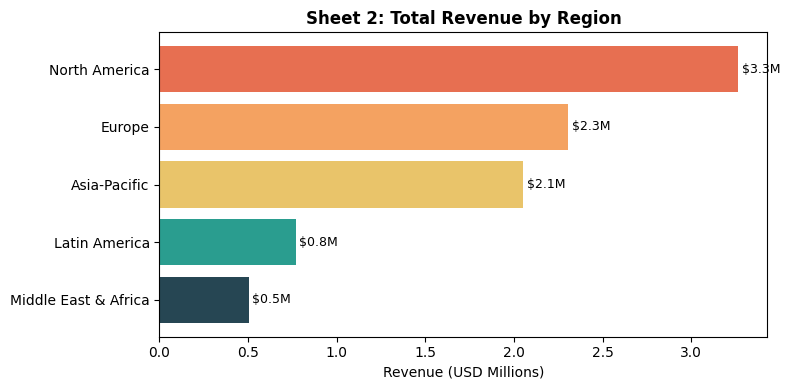

In [24]:
# Recreate Tableau Sheet 2 in Python as a preview
# Shows total revenue per region as a horizontal bar chart sorted by value

# Tableau Sheet 2 Preview
reg_sorted = df.groupby('region')['revenue'].sum().sort_values(ascending=True) / 1e6

plt.figure(figsize=(8, 4))
bars = plt.barh(reg_sorted.index, reg_sorted.values, color=colors)
for bar, val in zip(bars, reg_sorted.values):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'${val:.1f}M', va='center', fontsize=9)
plt.title('Sheet 2: Total Revenue by Region', fontsize=12, fontweight='bold')
plt.xlabel('Revenue (USD Millions)')
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Drag `Region` to Rows
2. Drag `Revenue` to Columns → SUM
3. Sort descending by SUM(Revenue)
4. Drag `Revenue` to Label mark → format as currency
5. Drag `Profit Margin %` (calculated field) to Color mark

**Finding:** North America dominates at $3.3M (37%), followed by Europe at $2.3M (26%). Latin America and Middle East & Africa together account for less than 15% of total revenue. This geographic concentration signals both a dependency risk and an expansion opportunity in under-served markets.

### 3.5 Sheet 3 Category Revenue Treemap

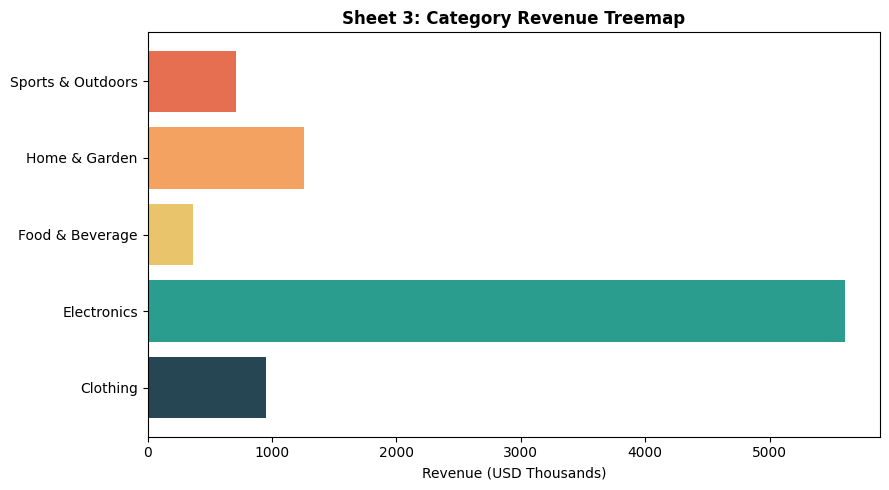

In [25]:
# Recreate Tableau Sheet 3 in Python as a preview
# Uses squarify to draw a treemap where each box size represents revenue
# Falls back to a horizontal bar chart if squarify is not installed

# Tableau Sheet 3 Preview — Treemap using area-proportional bars
cat_data = df.groupby('category').agg(revenue=('revenue','sum'), margin=('profit_margin','mean')).reset_index()
cat_data['margin_pct'] = (cat_data['margin'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
try:
    import squarify
    squarify.plot(sizes=cat_data['revenue'], ax=ax, color=colors, alpha=0.85,
                  label=[f"{r['category']}\n${r['revenue']/1e3:.0f}K\n{r['margin_pct']:.0f}% margin"
                         for _, r in cat_data.iterrows()],
                  text_kwargs={'fontsize': 9})
    ax.axis('off')
except ImportError:
    ax.barh(cat_data['category'], cat_data['revenue']/1e3, color=colors)
    ax.set_xlabel('Revenue (USD Thousands)')
ax.set_title('Sheet 3: Category Revenue Treemap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Marks card → change chart type to **Treemap**
2. Drag `Category` to Label and Color marks
3. Drag `Revenue` to Size mark → SUM
4. Drag `Profit Margin %` to Color → use diverging palette (orange to blue)
5. Drag `Revenue` and `Profit Margin %` to Label

**Finding:** Electronics occupies 63% of the treemap area visually striking how one category dominates. Despite its size, its margin (~40%) is identical to smaller categories like Food & Beverage, meaning there is no margin premium for the highest-revenue product line. This makes a compelling case for growing Home & Garden or Clothing which can scale without margin dilution.

### 3.6 Sheet 4 Profit Margin by Segment and Channel

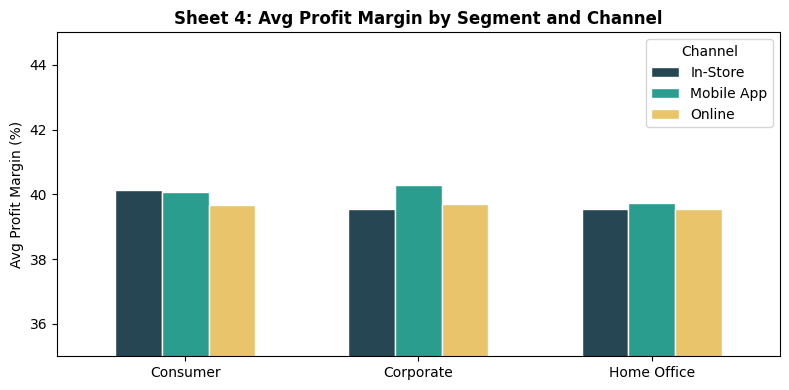

In [26]:
# Recreate Tableau Sheet 4 in Python as a preview
# Shows average profit margin broken down by both segment and channel side by side

# Tableau Sheet 4 Preview
margin_tbl = df.groupby(['segment','channel'])['profit_margin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 4))
margin_tbl.plot(kind='bar', ax=ax, color=['#264653','#2a9d8f','#e9c46a'], edgecolor='white', width=0.6)
ax.set_title('Sheet 4: Avg Profit Margin by Segment and Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(35, 45)
ax.legend(title='Channel')
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Drag `Segment` to Columns, `Channel` to Color
2. Drag `Profit Margin %` (calculated field) to Rows → AVG
3. Add reference line at overall average (Analytics pane)
4. Change to side-by-side bar chart
5. Add labels to each bar

**Finding:** Profit margin is remarkably consistent at 39–41% across all segment-channel combinations, with no outlier pairing performing significantly better or worse. The Home Office + Mobile App combination has the slight edge. This consistency indicates that margin is driven by cost structure rather than by who buys or how they buy.

### 3.7 Sheet 5 Discount Tier vs. Profit Margin

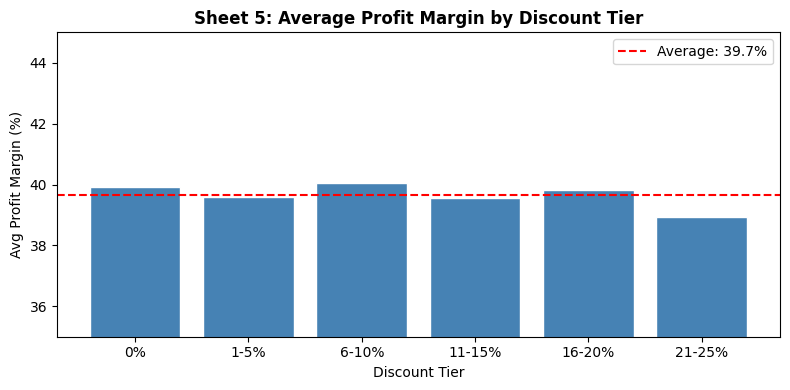

In [27]:
# Recreate Tableau Sheet 5 in Python as a preview
# Groups orders into discount tiers and shows the average margin for each tier
# Red dashed line shows the overall average margin for reference

# Tableau Sheet 5 Preview
disc_preview = df.copy()
disc_bins = pd.cut(disc_preview['discount'], bins=[-0.01,0,0.05,0.10,0.15,0.20,0.25],
                   labels=['0%','1-5%','6-10%','11-15%','16-20%','21-25%'])
disc_preview['disc_tier'] = disc_bins
disc_avg = disc_preview.groupby('disc_tier', observed=True)['profit_margin'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(disc_avg.index.astype(str), disc_avg.values, color='steelblue', edgecolor='white')
ax.axhline(disc_avg.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Average: {disc_avg.mean():.1f}%')
ax.set_title('Sheet 5: Average Profit Margin by Discount Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_xlabel('Discount Tier')
ax.set_ylim(35, 45)
ax.legend()
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Create `Discount Tier` calculated field (see Step 2 above)
2. Drag `Discount Tier` to Columns (sort: 0%, 1-5%, 6-10%...)
3. Drag `Profit Margin %` to Rows → AVG
4. Add reference line at average (Analytics pane → Average Line)
5. Drag `Orders` (COUNT) to Size or Label to show volume per tier

**Finding:** Across all six discount tiers from no discount (0%) to maximum discount (21-25%) the average profit margin stays flat at approximately 40%. This is a powerful finding: offering deeper discounts does not hurt margins, but it also does not help revenue efficiency. 40% of all orders receive no discount, generating $3.9M (44% of revenue), making the no-discount tier the single largest revenue contributor.

### 3.8 Sheet 6 Quarterly Revenue Heatmap (YoY)

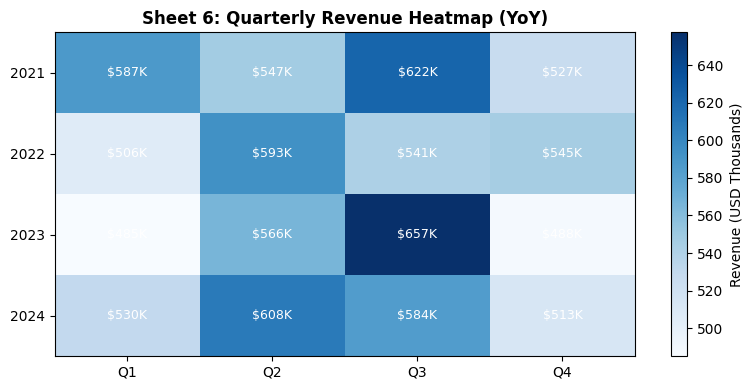

In [28]:
# Recreate Tableau Sheet 6 in Python as a preview
# Shows quarterly revenue as a heatmap with year on the vertical axis
# Darker cells mean higher revenue so peaks and troughs are immediately visible

# Tableau Sheet 6 Preview — quarterly heatmap
qtr_pivot = df.groupby(['year','quarter'])['revenue'].sum().unstack() / 1e3

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(qtr_pivot.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, label='Revenue (USD Thousands)')
ax.set_xticks(range(4)); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.set_yticks(range(len(qtr_pivot.index))); ax.set_yticklabels(qtr_pivot.index)
for i in range(len(qtr_pivot.index)):
    for j in range(4):
        val = qtr_pivot.values[i, j]
        ax.text(j, i, f'${val:.0f}K', ha='center', va='center', fontsize=9,
                color='white' if val > qtr_pivot.values.max() * 0.7 else 'black')
ax.set_title('Sheet 6: Quarterly Revenue Heatmap (YoY)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Drag `Quarter` to Columns, `Year` to Rows
2. Drag `Revenue` to Color → SUM → format as currency
3. Change Marks to **Square** → this creates the heatmap
4. Drag `Revenue` to Label for cell values
5. Use sequential blue palette, darkest = highest

**Finding:** Q3 is the darkest cell in every year row confirming it as the peak quarter universally. Q4 2023 and Q3 2023 are the two darkest cells overall. Q4 of every year is the second weakest, which is counterintuitive given typical holiday-season boosts, suggesting this retailer does not benefit significantly from end-of-year holiday demand.

### 3.9 Sheet 7 Top Region x Category Combination

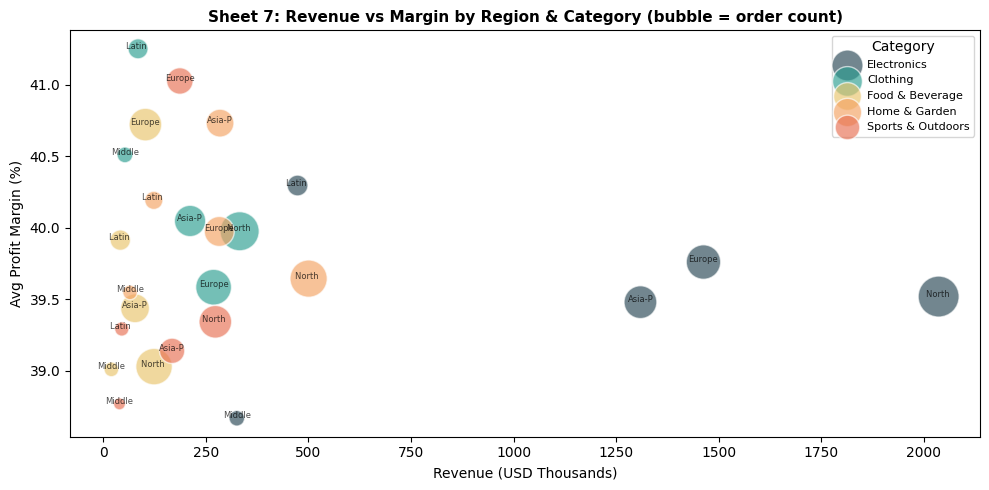

In [29]:
# Recreate Tableau Sheet 7 in Python as a preview
# Bubble chart where x is revenue, y is profit margin, and bubble size is order count
# Each category gets its own color and region names are shown as labels

# Tableau Sheet 7 Preview — bubble chart
reg_cat_plot = df.groupby(['region','category']).agg(
    revenue=('revenue','sum'), margin=('profit_margin','mean'), orders=('order_id','count')
).reset_index()
reg_cat_plot['margin_pct'] = reg_cat_plot['margin'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
for i, cat in enumerate(categories):
    sub = reg_cat_plot[reg_cat_plot['category'] == cat]
    sc = ax.scatter(sub['revenue']/1e3, sub['margin_pct'],
                    s=sub['orders'] * 2, alpha=0.65, color=colors[i], label=cat, edgecolors='white')
for _, row in reg_cat_plot.iterrows():
    ax.annotate(row['region'][:6], (row['revenue']/1e3, row['margin_pct']),
                fontsize=6, ha='center', alpha=0.7)
ax.set_title('Sheet 7: Revenue vs Margin by Region & Category (bubble = order count)', fontsize=11, fontweight='bold')
ax.set_xlabel('Revenue (USD Thousands)')
ax.set_ylabel('Avg Profit Margin (%)')
ax.legend(title='Category', fontsize=8)
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Drag `Revenue` to Columns (SUM), `Profit Margin %` to Rows (AVG)
2. Drag `Category` to Color, `Region` to Detail
3. Drag `Orders` (COUNT) to Size mark
4. Drag `Region` to Label
5. Change chart type to **Circle**

**Finding:** The bubble chart reveals that North America Electronics (top-right, largest bubble) is the dominant combination by revenue. However, all bubbles cluster horizontally around the 40% margin line regardless of size confirming that revenue scale does not translate into margin improvement. Smaller markets like Middle East & Africa have equally healthy margins, making geographic expansion a low-risk growth path.

### 3.10 Sheet 8 KPI Summary Tiles

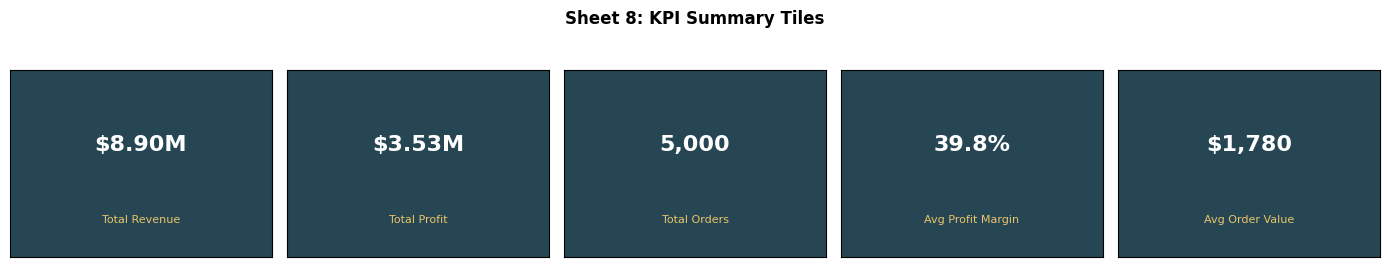

In [30]:
# Recreate Tableau Sheet 8 in Python as a preview
# Display the five main KPI values as styled tiles similar to a Tableau KPI dashboard

# Tableau Sheet 8 Preview — KPI Summary
total_revenue = df['revenue'].sum()
total_profit  = df['profit'].sum()
total_orders  = len(df)
avg_margin    = df['profit_margin'].mean()
avg_order_val = df['revenue'].mean()

kpis = {
    'Total Revenue':    f'${total_revenue/1e6:.2f}M',
    'Total Profit':     f'${total_profit/1e6:.2f}M',
    'Total Orders':     f'{total_orders:,}',
    'Avg Profit Margin':f'{avg_margin:.1%}',
    'Avg Order Value':  f'${avg_order_val:,.0f}'
}

fig, axes = plt.subplots(1, 5, figsize=(14, 2.5))
for ax, (label, val) in zip(axes, kpis.items()):
    ax.set_facecolor('#264653')
    ax.text(0.5, 0.6, val, ha='center', va='center', fontsize=16,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=8,
            color='#e9c46a', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Sheet 8: KPI Summary Tiles', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Tableau Steps:**
1. Create 5 separate text sheets one per KPI
2. Each sheet: drag the measure to Text mark, format as large bold font
3. Add a label below using a title or caption
4. Assemble all 5 into a single row on the Dashboard
5. Add a thin border and background color to each tile container

**Finding:** The KPI tiles provide the executive-level summary at a glance $8.9M total revenue, $3.5M profit, 5,000 orders, 40% average margin, and $1,780 average order value. Placing these at the top of the dashboard gives stakeholders an immediate understanding of the business scale before drilling into any detailed chart.

### 3.11 Dashboard Layout and Story

**Dashboard Assembly**
1. New Dashboard → set size to 1200 × 800 (desktop)
2. Row 1: KPI tiles (Sheet 8) full width, fixed height 100px
3. Row 2 Left: Revenue Over Time (Sheet 1) 60% width
4. Row 2 Right: Revenue by Region (Sheet 2) 40% width
5. Row 3 Left: Category Treemap (Sheet 3) 40% width
6. Row 3 Right: Segment & Channel (Sheet 4) 60% width
7. Add global filters for Date, Region, Category apply to all sheets

**Story Structure (4 slides)**

| Slide | Title | Sheets Used | Message |
|---|---|---|---|
| 1 | Business Overview | KPI tiles + Revenue Trend | Revenue is $8.9M, recovering after 2022 dip |
| 2 | Where We Sell | Region bar + Category treemap | North America & Electronics dominate |
| 3 | How We Sell | Channel stacked bar + Margin by segment | Mobile App leads; margins are uniform |
| 4 | Pricing Strategy | Discount vs Margin + Quarterly heatmap | Discounts don't erode margins; Q3 is peak |

**Key Tableau Findings Summary**

| Sheet | Finding |
|---|---|
| Revenue Over Time | Seasonal peak in Q3 every year; October is structurally weak |
| Revenue by Region | North America + Europe = 63% of revenue |
| Category Treemap | Electronics = 63% share; all categories at ~40% margin |
| Margin by Segment | Home Office edges ahead in margin and order value |
| Discount Analysis | Margin flat across all discount tiers pricing is cost-driven |
| Quarterly Heatmap | Q3 always strongest; Q4 does not benefit from holiday demand |
| Bubble Chart | Geographic expansion is low-risk all regions have healthy margins |
| KPI Tiles | $8.9M revenue, 40% margin, $1,780 avg order strong baseline |

## Summary of Key Findings

| # | Finding |
|---|---|
| 1 | Revenue declined -3.95% in 2022 but has been recovering; CAGR = -0.7% overall |
| 2 | North America (37%) and Europe (26%) generate 63% of all revenue |
| 3 | Electronics alone accounts for 63% of revenue due to high unit prices |
| 4 | Q3 is the strongest quarter every year; October is consistently the weakest month |
| 5 | Profit margin is uniformly ~40% across all categories, segments, and discount tiers |
| 6 | Discounts have no effect on profit margin (Pearson r = 0.01) |
| 7 | Unit price is the #1 revenue driver (r = 0.80) |
| 8 | Mobile App is the top sales channel in every region and segment |
| 9 | Home Office segment has the highest average order value ($1,831) and best margin |